# ***Preliminary Signal Analysis on the Brownfield CNC Milling Machines Dataset***




In [1]:
#  === LOAD LIBRARIES===
import os
import sys
import h5py
import numpy as np
import matplotlib.pyplot as plt
from typing import Literal
from scipy import signal, stats

### Load Data from Dataset

In [2]:
def find_all_h5s_in_dir(s_dir: os.PathLike):
    """
    list all .h5 files in a directory and subdirectories
    """
    fileslist = []
    for root, _, files in os.walk(s_dir):
        for file in files:
            if file.endswith(".h5"):
                fileslist.append(os.path.join(root, file))  # percorso completo!
    return fileslist


def load_tool_research_data(data_path: os.PathLike, label: Literal["good","bad"], add_additional_label: bool =True, verbose: bool =True):
    """
    load data (good and bad) from the research data storages
    
    Keyword Arguments:
            data_path {str} -- [path to the directory] 
            label {str} -- ["good" or "bad"]
            add_additional_label {bool} -- [if true the labels will be in the form of "Mxx_Aug20xx_OPxx_sampleNr_label" otherwise "label"] (default: True)
            verbose {bool}

        Returns:
            datalist --  [list of the the X samples]
            label --  [list of the the y labels ]
    """
    datalist = []
    data_label = []

    # list all .h5 files
    list_paths = find_all_h5s_in_dir(data_path)
    list_paths.sort()
    if not list_paths and verbose:
        print(f"skipping {data_path} empty directory...")

    # read and append the samples with the corresponding labels
    if verbose:
        print(f"loading files from {data_path}... ")
    for element in list_paths:
        # check if additional label needed ("Mxx_Aug20xx_Tool,nrX") 
        if add_additional_label:
            add_label = element.split('/')[-1]
            additional_label = add_label[:-3] + "_" + label
        else:
            additional_label = label
        # extract data X and y 
        with h5py.File(os.path.join(data_path, element), 'r') as f:
            vibration_data = f['vibration_data'][:]
        datalist.append(vibration_data)
        data_label.append(additional_label)

    return datalist, data_label


def data_printing(vibration_data: np.ndarray, plotting=True):
    """Plots vibration data already loaded in memory, identico allo stile originale.

    Keyword Arguments:
        vibration_data {ndarray} -- array dei dati già caricati, shape (N, 3)
        plotting {bool} -- se True mostra i grafici (default: True)

    Returns:
        ndarray -- dati originali (stesso input)
    """
    # interpolation for x axis plot
    freq = 2000
    samples_s = len(vibration_data[:, 0]) / freq
    samples = np.linspace(0, samples_s, len(vibration_data[:, 0]))

    # plotting identico alla funzione originale
    if plotting:
        plt.figure(figsize=(20, 5))
        plt.plot(samples, vibration_data[:, 0], 'b')
        plt.ylabel('X-axis Vibration Data')
        plt.xlabel('Time [sec]')
        plt.locator_params(axis='y', nbins=10)
        plt.grid()
        plt.show()
        
        '''plt.figure(figsize=(20, 5))
        plt.plot(samples, vibration_data[:, 1], 'b')
        plt.ylabel('Y-axis Vibration Data')
        plt.xlabel('Time [sec]')
        plt.locator_params(axis='y', nbins=10)
        plt.grid()
        plt.show()
        
        plt.figure(figsize=(20, 5))
        plt.plot(samples, vibration_data[:, 2], 'b')
        plt.ylabel('Z-axis Vibration Data')
        plt.xlabel('Time [sec]')
        plt.locator_params(axis='y', nbins=10)
        plt.grid()
        plt.show()'''
    
    return vibration_data

In [3]:
datalist, data_label = load_tool_research_data(data_path="../data", label="good")
print(len(datalist), datalist[0].shape, data_label[0])

loading files from ../data... 
1702 (268288, 3) M01_Aug_2019_OP00_000_good


# ***Preliminary Analysis of the Accelerometer Signal***

The data were collected from a tri-axial sensor mounted on the rear of the spindle housing of a CNC machine, with a sampling frequency of **fs = 2 kHz**, in order to fully capture spindle vibrations up to the maximum analyzable frequency of 1 kHz, according to the Nyquist theorem.

The original signal shows significant components around the spindle frequency (approximately 250 Hz) and its higher harmonics, as expected for a real mechanical system: the signal is not a pure sine wave but exhibits distortions due to structural vibrations and tool-workpiece interactions. Low-frequency components (<75 Hz) mainly correspond to slow machine movements or environmental noise, which are not relevant for vibration analysis.

To isolate the relevant components, a **fourth-order Butterworth high-pass filter with a 75 Hz cutoff** was applied. This removes low-frequency components while fully preserving critical components between 75 Hz and 1 kHz, including spindle harmonics necessary for defect analysis or as input to Machine Learning models.

Frequency analysis, performed via **Power Spectral Density (PSD) using Welch’s method**, clearly highlights the main peaks around 250 Hz and harmonics up to approximately 1 kHz. The PSD is represented in **decibels (20·log₁₀(Pxx))** to better emphasize differences between the original and filtered signals and to make low-energy components more readable.

Observing the filtered signals, low-frequency components associated with slow vibrations or environmental noise are effectively removed, while high-frequency components representing significant spindle vibrations are preserved. This approach ensures that subsequent Machine Learning models analyze only the relevant information for machine condition monitoring and mechanical anomaly detection.

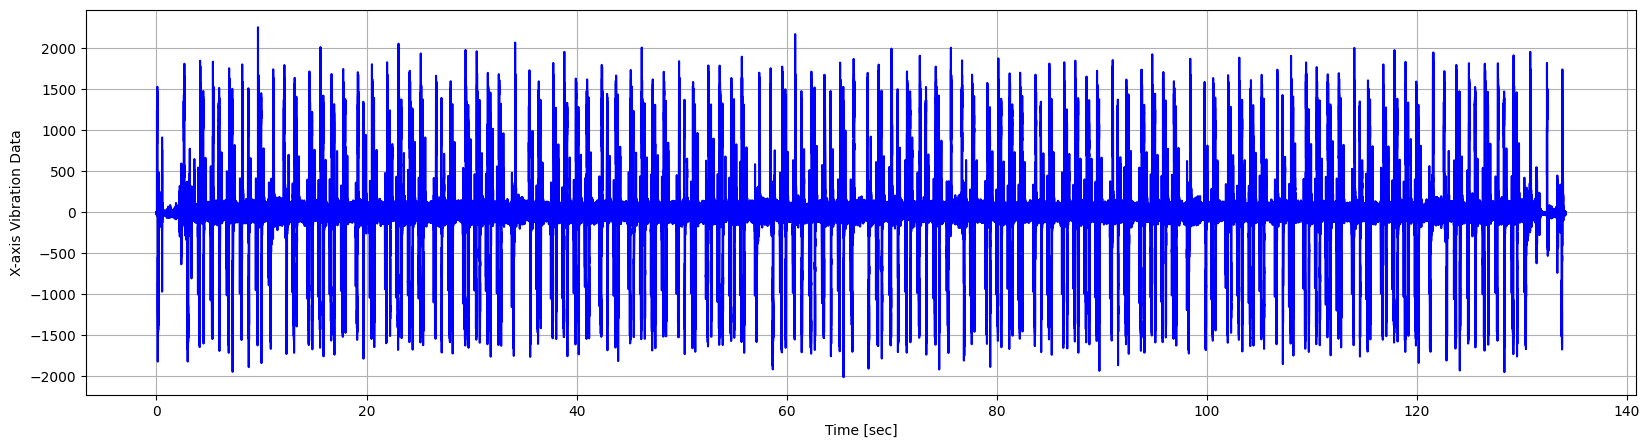

array([[   -9.,     9., -1011.],
       [  -21.,    19., -1011.],
       [  -15.,    23., -1020.],
       ...,
       [  -13.,    33., -1015.],
       [  -13.,    27., -1016.],
       [  -31.,    25., -1020.]])

In [4]:
data_printing(vibration_data=datalist[0])

# ***High-Pass Filtering of CNC Spindle Vibration Signals***

Before analyzing the signal for machine condition monitoring, we remove low-frequency components (<75 Hz) that correspond to slow machine movements or environmental noise.  

The spindle vibrations, including the fundamental frequency (~250 Hz) and its harmonics, are preserved in the frequency range **75 Hz – 1 kHz**, which is relevant for detecting anomalies and feeding Machine Learning models.  

We apply a **4th-order Butterworth high-pass filter** with a cutoff frequency at **75 Hz** to isolate these useful vibration components while eliminating unwanted low-frequency noise.


X-axis: max 2246.00 → 1498.62, std 424.58 → 87.91


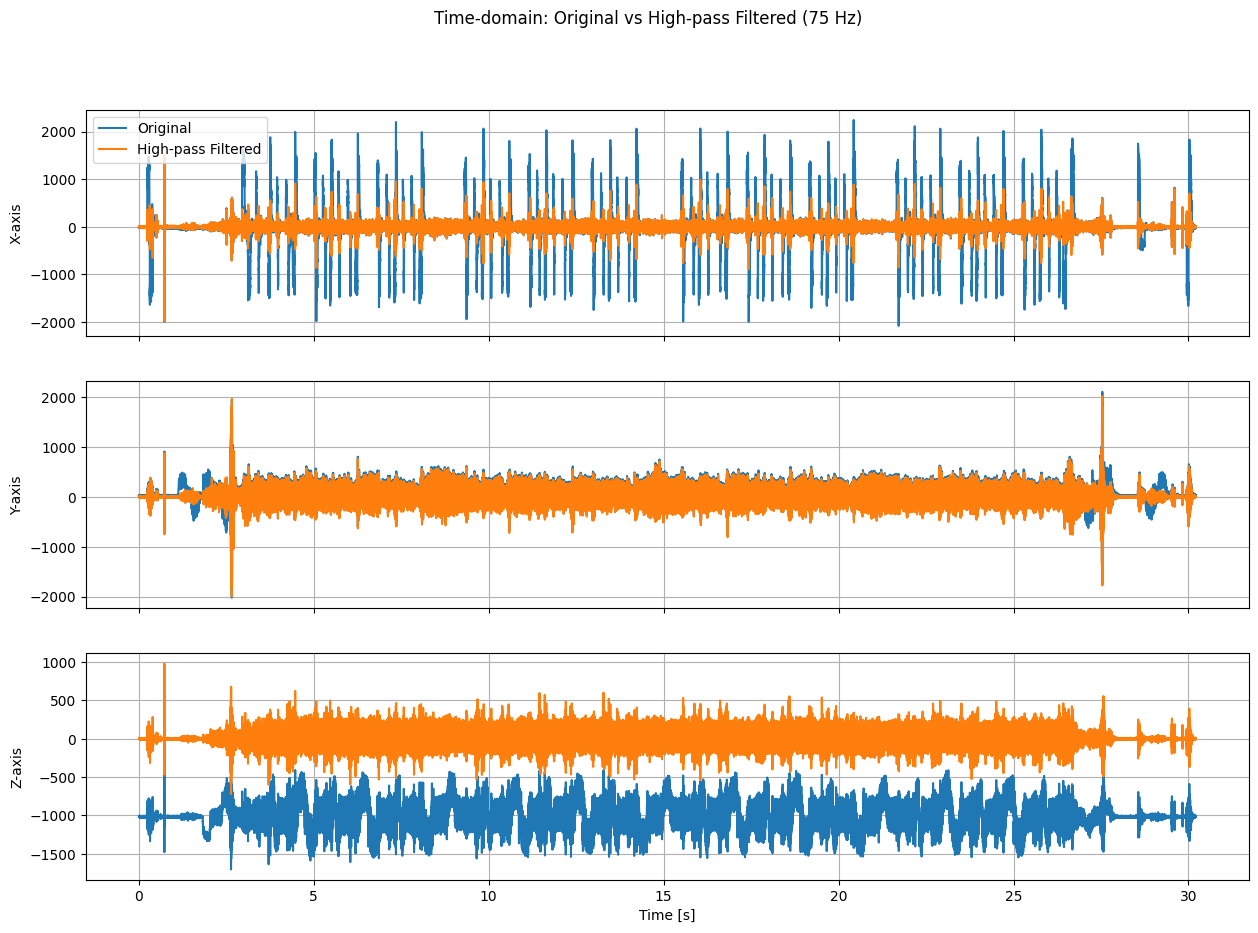

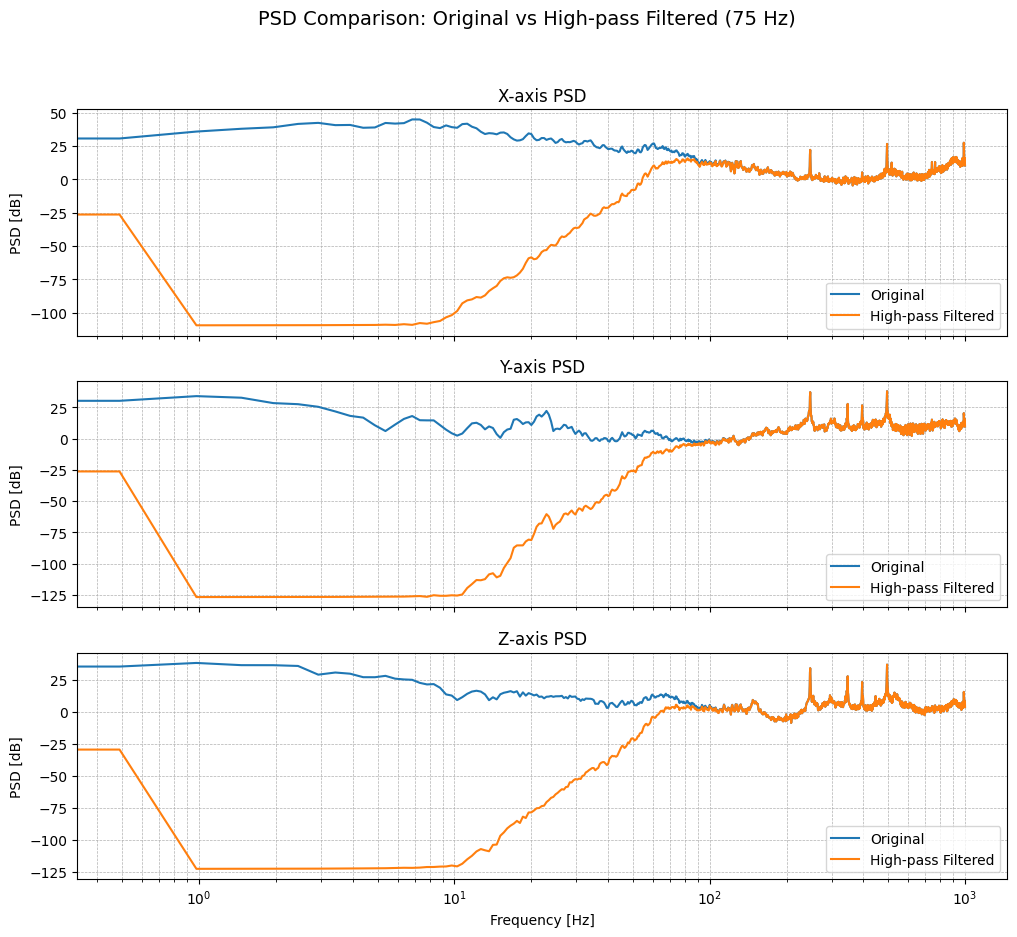

Y-axis: max 2110.00 → 2023.50, std 169.52 → 155.27
Z-axis: max -27.00 → 981.57, std 168.83 → 111.03
X-axis: max 2108.00 → 1318.04, std 427.31 → 87.79
Y-axis: max 2002.00 → 1937.88, std 171.14 → 156.54
Z-axis: max -269.00 → 727.04, std 168.21 → 108.68
X-axis: max 2543.00 → 1200.72, std 434.65 → 96.45
Y-axis: max 1856.00 → 1989.20, std 164.63 → 152.12
Z-axis: max -234.00 → 747.10, std 175.04 → 114.69
X-axis: max 2264.00 → 1515.93, std 428.17 → 92.43
Y-axis: max 1594.00 → 1780.59, std 164.68 → 148.04
Z-axis: max -212.00 → 768.94, std 159.51 → 94.44
X-axis: max 2090.00 → 1024.85, std 424.64 → 90.47
Y-axis: max 1944.00 → 1897.92, std 159.91 → 143.59
Z-axis: max -218.00 → 772.99, std 158.74 → 94.64
X-axis: max 2155.00 → 1581.40, std 424.14 → 91.19
Y-axis: max 1963.00 → 1938.73, std 159.38 → 142.45
Z-axis: max -306.00 → 684.08, std 159.41 → 95.64
X-axis: max 2141.00 → 1042.02, std 427.51 → 88.22
Y-axis: max 2110.00 → 2027.90, std 173.98 → 159.82
Z-axis: max -257.00 → 692.63, std 170.99 → 112.

In [5]:
# === High-Pass Filter ===
def butter_highpass(x, fs, cutoff=75, order=4):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = signal.butter(order, normal_cutoff, btype='high', analog=False)
    return signal.filtfilt(b, a, x)

# === METRICHE ===
def compute_metrics(x):
    return {
        'max': np.max(x),
        'min': np.min(x),
        'mean': np.mean(x),
        'std': np.std(x),
        'energy': np.sum(x**2),
        'kurtosis': stats.kurtosis(x, fisher=False)
    }

# === PSD in dB without offset ===
def psd_plot_db(x, fs=2000, ax=None, label=None):
    f, Pxx = signal.welch(x, fs=fs, nperseg=4096)
    Pxx_db = 10 * np.log10(Pxx)  # conversione standard MATLAB
    ax.semilogx(f, Pxx_db, label=label, linewidth=1.5)
    ax.set_ylabel('PSD [dB]')
    ax.grid(True, which='both', linestyle='--', linewidth=0.5)

# === PARAMETRI ===
relevant_data = []
for i in range(31,69):
    relevant_data.append(datalist[i]) # Nx3
fs = 2000
axes_labels = ['X','Y','Z']
cutoff = 75
order = 4
filtered_signals = []
k=0
for j, el in enumerate(relevant_data):
    # === Filtering ===
    filtered_data = np.zeros_like(el)
    for i in range(3):
        filtered_data[:, i] = butter_highpass(el[:, i], fs, cutoff, order)
    filtered_signals.append(filtered_data)
    # === Metrics ===
    for i, label in enumerate(axes_labels):
        orig = compute_metrics(el[:, i])
        filt = compute_metrics(filtered_data[:, i])
        print(f"{label}-axis: max {orig['max']:.2f} → {filt['max']:.2f}, std {orig['std']:.2f} → {filt['std']:.2f}")
        # === PLOT SEGNALE TEMPORALE ===
        if k==0:
            t = np.arange(len(el)) / fs
            fig, axs = plt.subplots(3,1, figsize=(15,10), sharex=True)
            for i, label in enumerate(axes_labels):
                axs[i].plot(t, el[:, i], label='Original', linewidth=1.5)
                axs[i].plot(t, filtered_data[:, i], label='High-pass Filtered', linewidth=1.5)
                axs[i].set_ylabel(f'{label}-axis')
                axs[i].grid()
            axs[0].legend()
            axs[-1].set_xlabel('Time [s]')
            fig.suptitle(f'Time-domain: Original vs High-pass Filtered ({cutoff} Hz)')
            plt.show()

            # === PLOT PSD IN dB ===
            fig, axs = plt.subplots(3,1, figsize=(12,10), sharex=True)
            for i, label in enumerate(axes_labels):
                psd_plot_db(el[:, i], fs=fs, ax=axs[i], label='Original')
                psd_plot_db(filtered_data[:, i], fs=fs, ax=axs[i], label='High-pass Filtered')
                axs[i].legend()
                axs[i].set_title(f'{label}-axis PSD')
            axs[-1].set_xlabel('Frequency [Hz]')
            fig.suptitle(f'PSD Comparison: Original vs High-pass Filtered ({cutoff} Hz)', fontsize=14)
            plt.show()
        k +=1

# **Visualize Others OP in the Same Machine.**

1702 (268288, 3) M01_Aug_2019_OP00_000_good
1702 (268288, 3) M01_Aug_2019_OP00_001_good
1702 (268288, 3) M01_Aug_2019_OP00_003_good
1702 (264192, 3) M01_Aug_2019_OP00_004_good
1702 (268288, 3) M01_Aug_2019_OP00_008_good
1702 (266400, 3) M01_Feb_2019_OP00_000_good
1702 (60416, 3) M01_Aug_2019_OP01_000_good


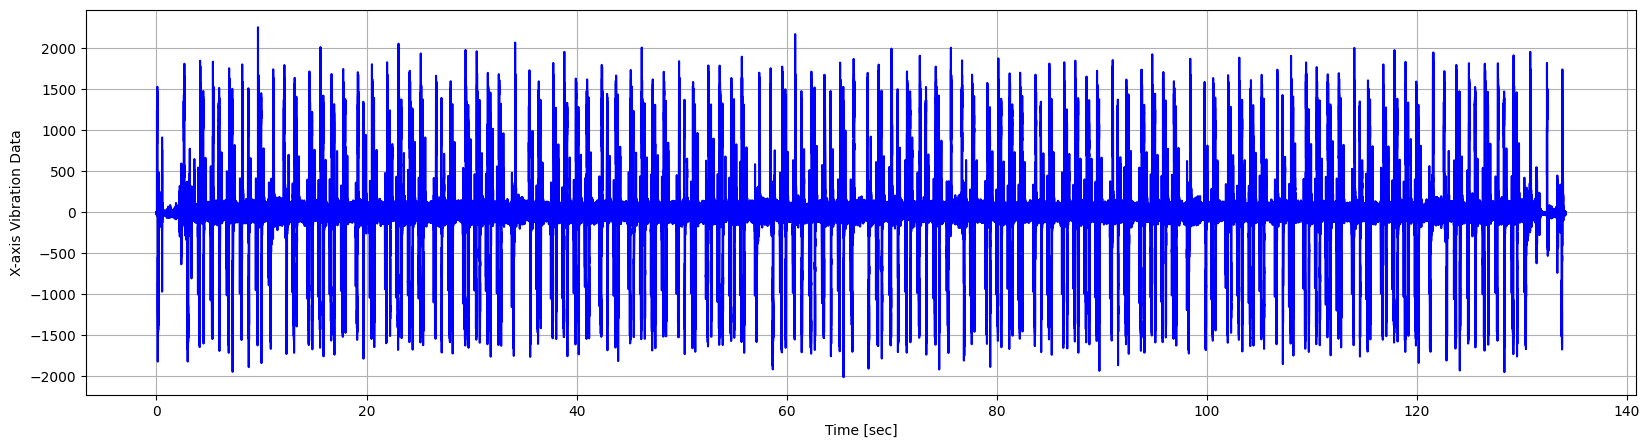

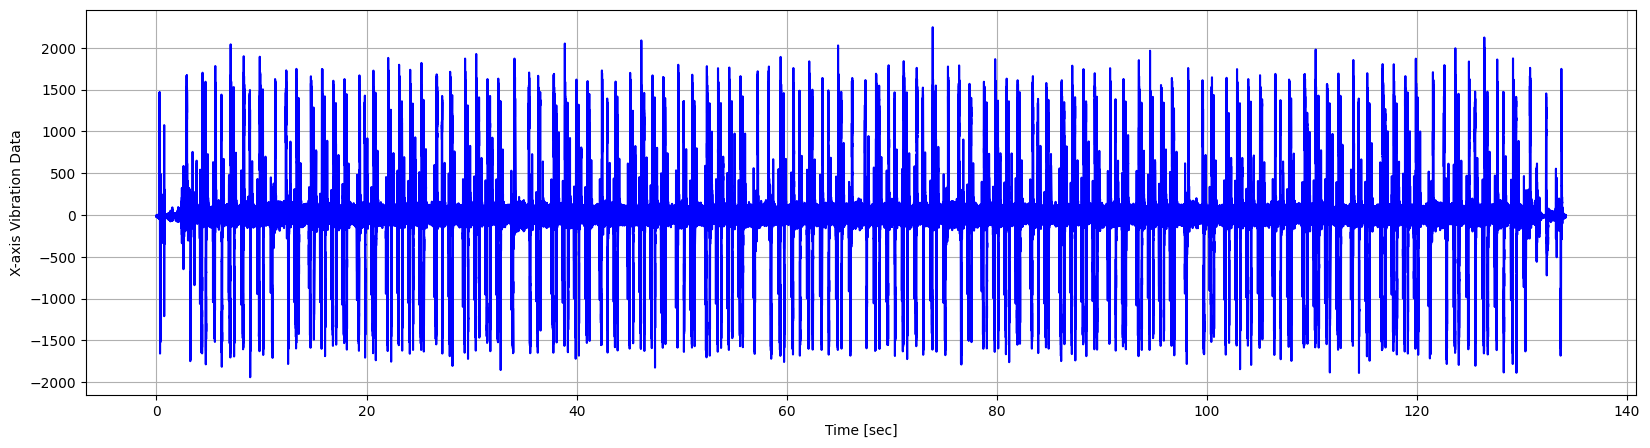

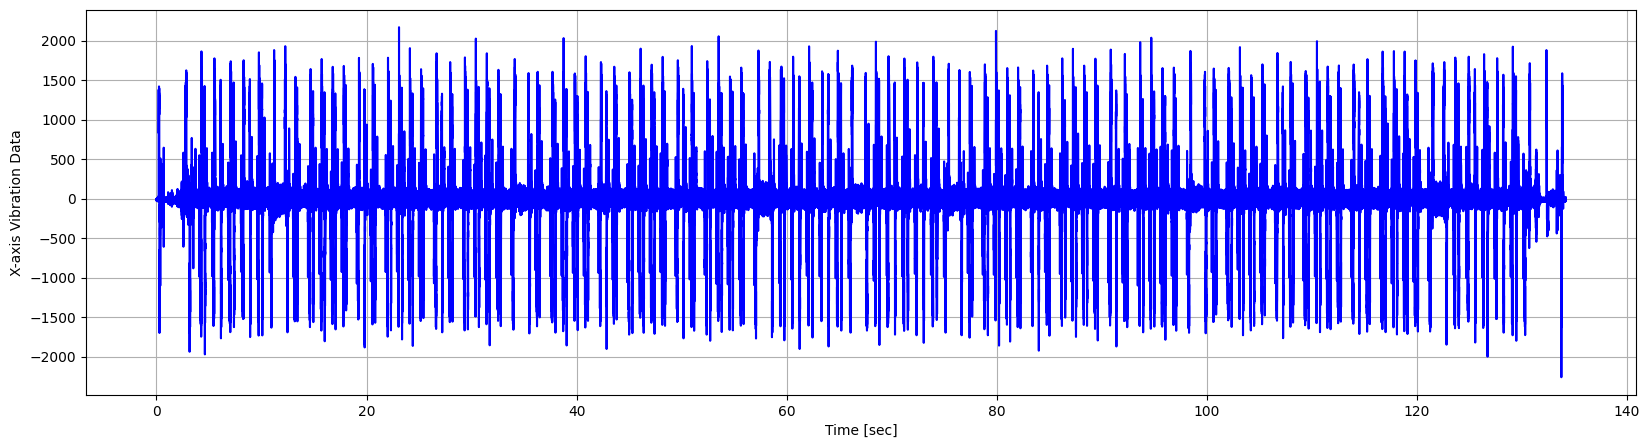

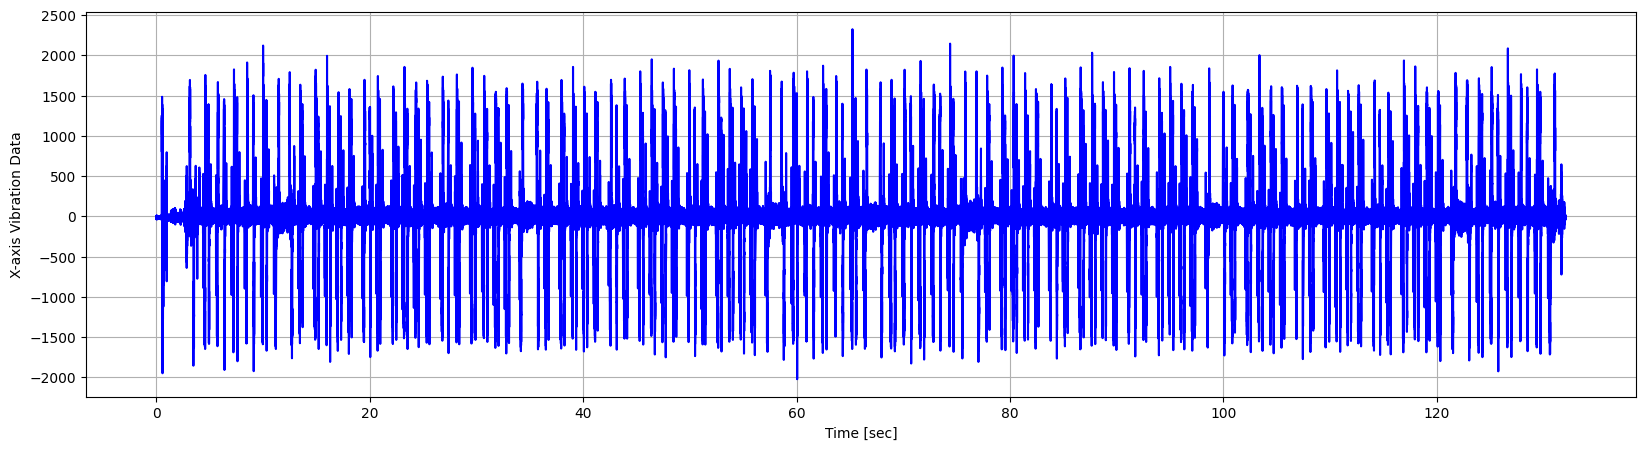

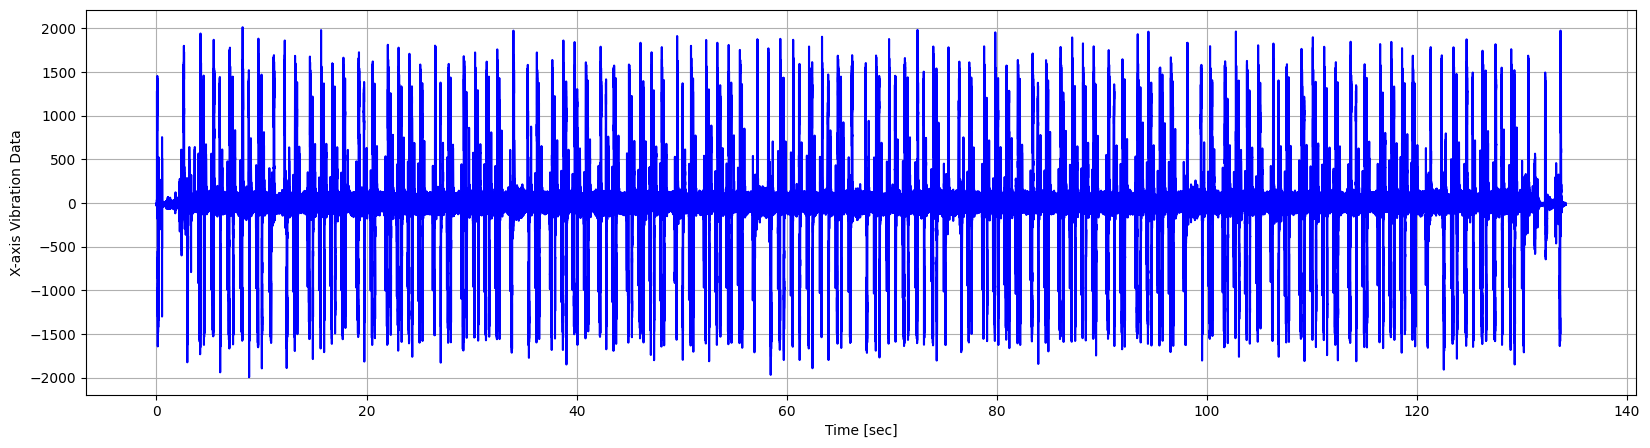

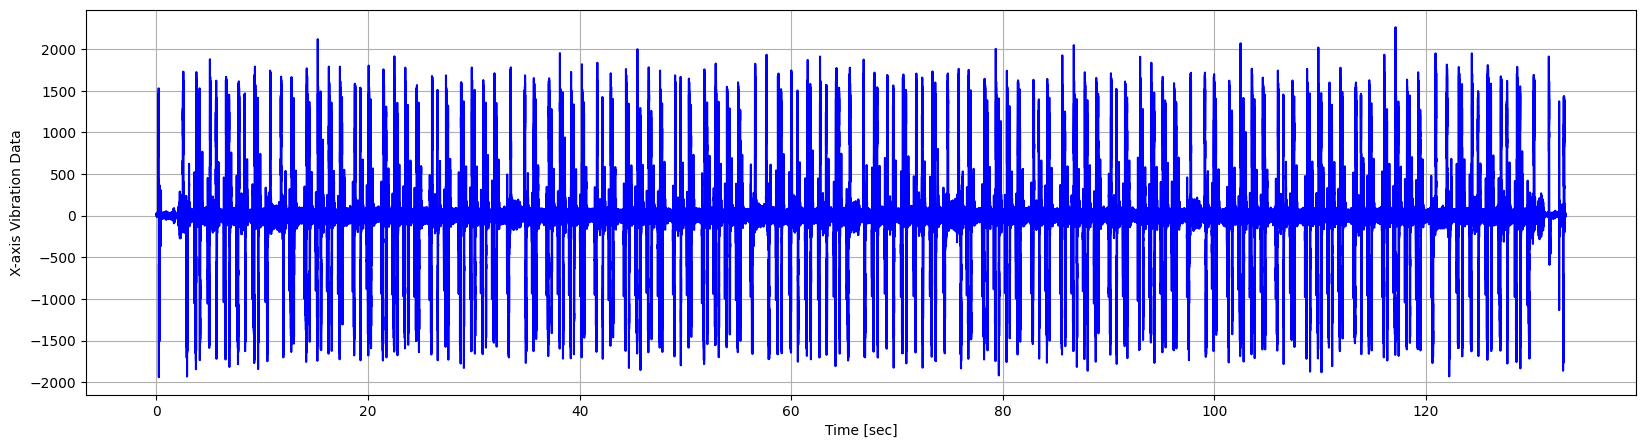

array([[   11.,    25., -1036.],
       [   15.,    31., -1038.],
       [    0.,    27., -1042.],
       ...,
       [   11.,    40., -1036.],
       [   15.,    52., -1036.],
       [   13.,    42., -1024.]], dtype=float32)

In [6]:
print(len(datalist), datalist[0].shape, data_label[0])#-> da 0 a 28 sono la prima componente OP00
print(len(datalist), datalist[1].shape, data_label[1]) 
print(len(datalist), datalist[2].shape, data_label[2])
print(len(datalist), datalist[3].shape, data_label[3])
print(len(datalist), datalist[7].shape, data_label[7])
print(len(datalist), datalist[15].shape, data_label[15])
print(len(datalist), datalist[31].shape, data_label[31])
data_printing(vibration_data=datalist[0])
data_printing(vibration_data=datalist[1])
data_printing(vibration_data=datalist[2])
data_printing(vibration_data=datalist[3])
data_printing(vibration_data=datalist[7])
data_printing(vibration_data=datalist[15])

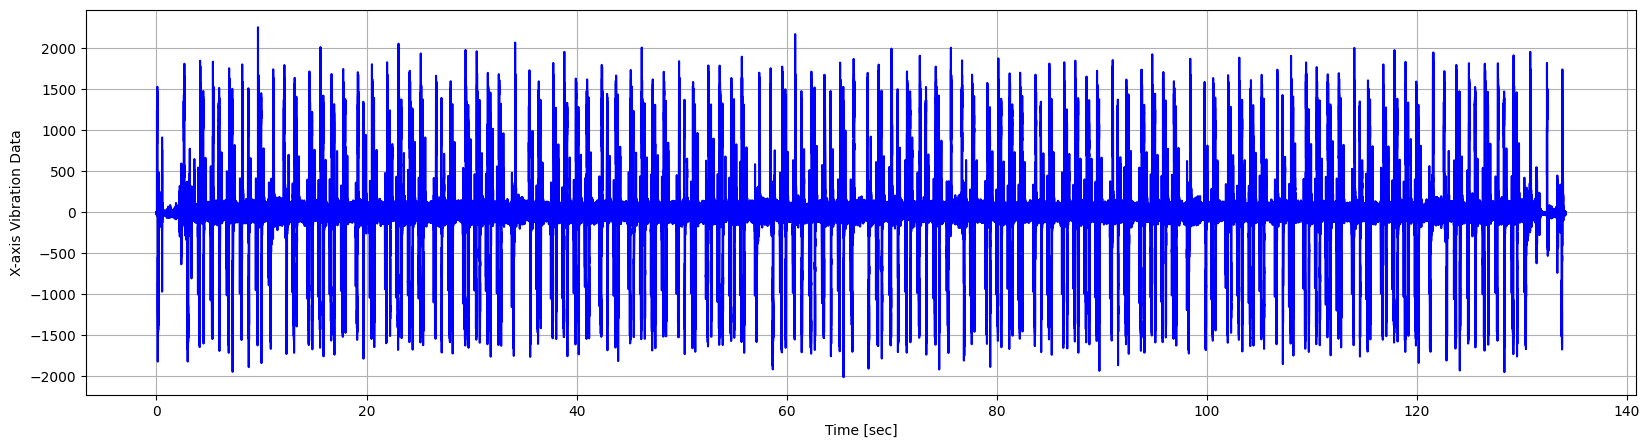

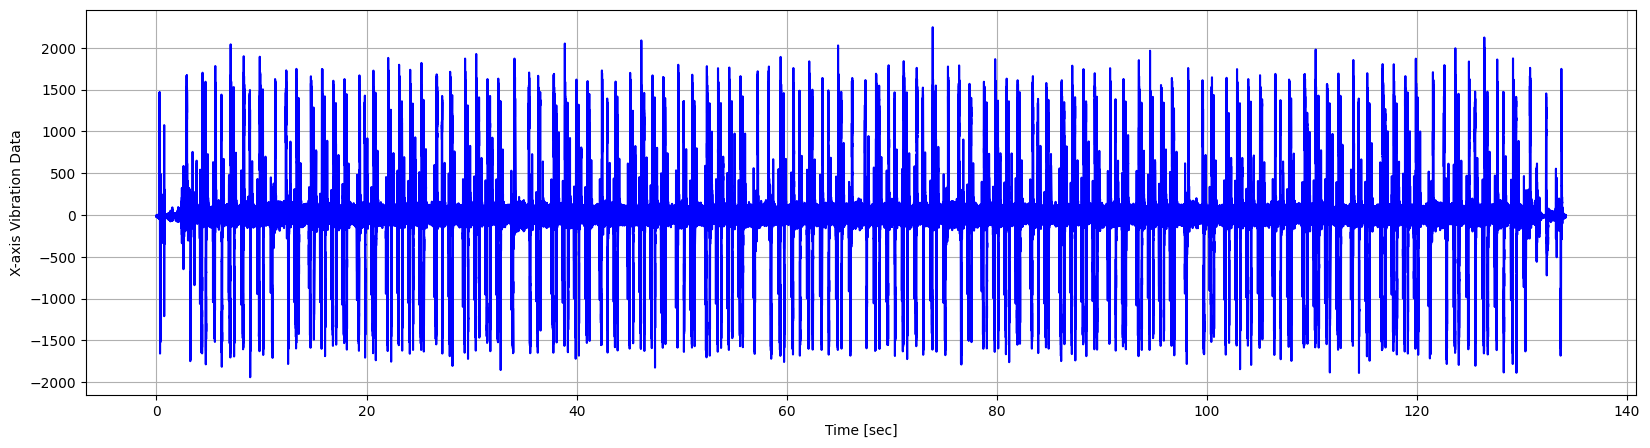

array([[  -15.,    21., -1009.],
       [  -13.,    23., -1013.],
       [  -13.,    19., -1009.],
       ...,
       [   -5.,     7., -1028.],
       [  -11.,    21., -1022.],
       [   -5.,    15., -1005.]])

In [7]:
data_printing(vibration_data=datalist[0])
data_printing(vibration_data=datalist[1])

=== Normalized Metrics ===
X-axis:
  Spearman correlation: -0.021
  Pearson correlation : -0.027
  RMSE               : 1.433

Y-axis:
  Spearman correlation: -0.030
  Pearson correlation : -0.009
  RMSE               : 1.421

Z-axis:
  Spearman correlation: 0.021
  Pearson correlation : 0.035
  RMSE               : 1.389



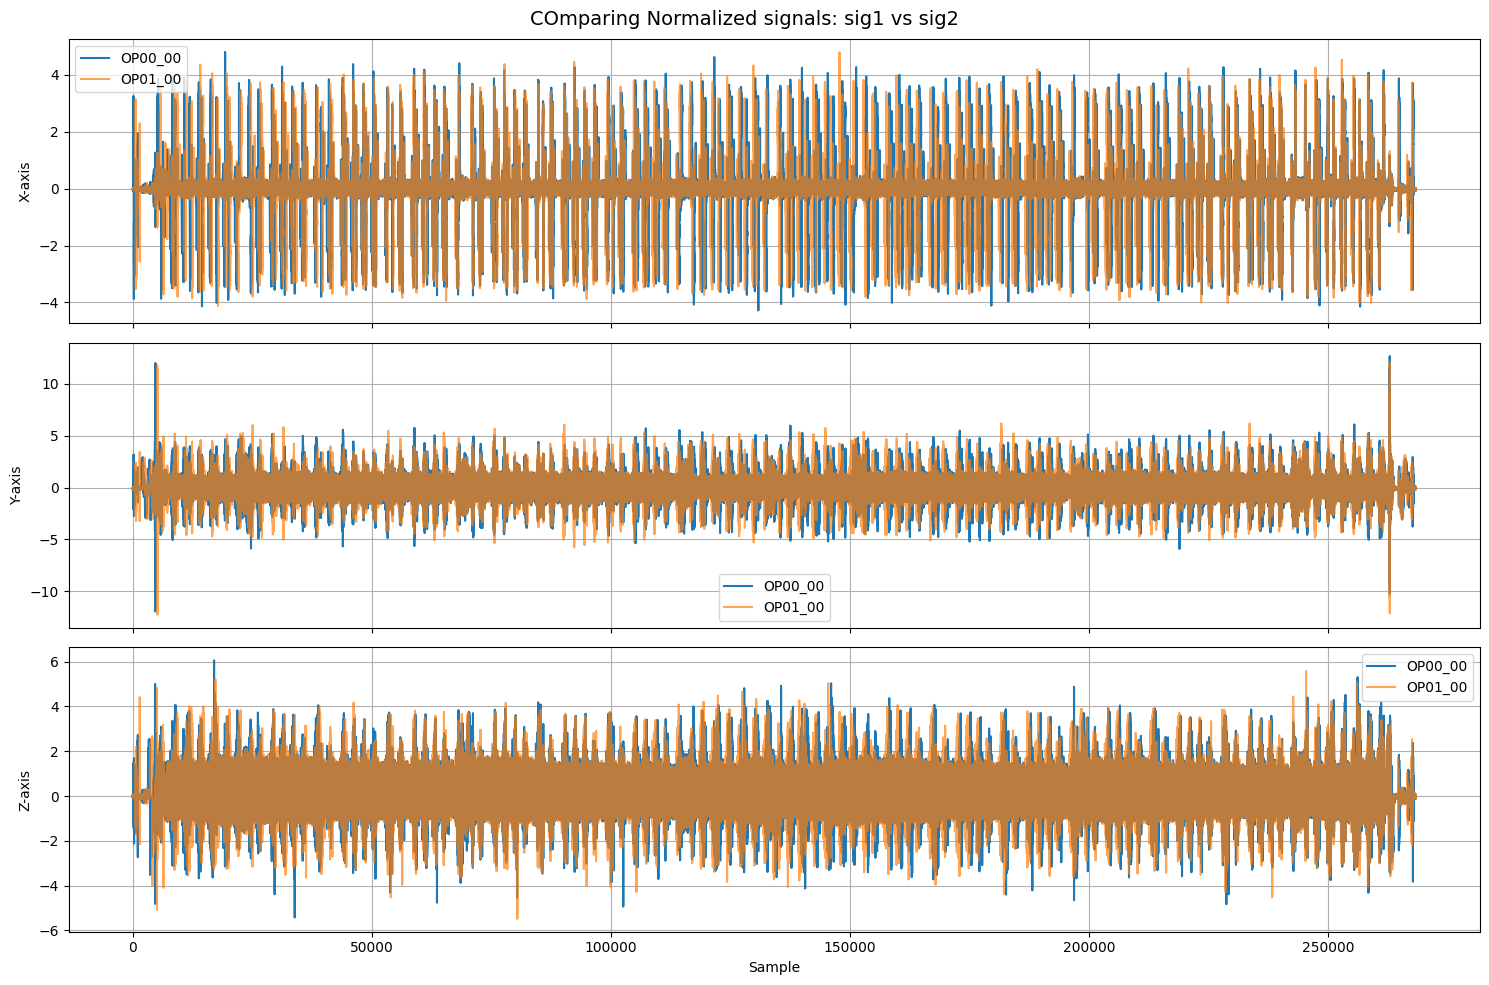

In [8]:
import numpy as np
from scipy.stats import spearmanr, pearsonr
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# segnali
sig1 = datalist[0]
sig2 = datalist[1]

# Cut the first signal on the length of second
target_len = len(sig2)
sig1 = sig1[:target_len, :]

axes_labels = ['X', 'Y', 'Z']

print("=== Normalized Metrics ===")
for i, label in enumerate(axes_labels):
    # normalizzazione (rimuove offset e scala)
    x1 = (sig1[:, i] - np.mean(sig1[:, i])) / np.std(sig1[:, i])
    x2 = (sig2[:, i] - np.mean(sig2[:, i])) / np.std(sig2[:, i])

    # metriche
    spearman_corr, _ = spearmanr(x1, x2)
    pearson_corr, _ = pearsonr(x1, x2)
    rmse = np.sqrt(mean_squared_error(x1, x2))

    print(f"{label}-axis:")
    print(f"  Spearman correlation: {spearman_corr:.3f}")
    print(f"  Pearson correlation : {pearson_corr:.3f}")
    print(f"  RMSE               : {rmse:.3f}\n")

# === Overlay plot of normalized signals ===
t = np.arange(target_len)  # asse temporale

fig, axs = plt.subplots(3, 1, figsize=(15, 10), sharex=True)
for i, label in enumerate(axes_labels):
    x1 = (sig1[:, i] - np.mean(sig1[:, i])) / np.std(sig1[:, i])
    x2 = (sig2[:, i] - np.mean(sig2[:, i])) / np.std(sig2[:, i])
    axs[i].plot(t, x1, label='OP00_00', linewidth=1.5)
    axs[i].plot(t, x2, label='OP01_00', linewidth=1.5, alpha=0.7)
    axs[i].set_ylabel(f'{label}-axis')
    axs[i].grid()
    axs[i].legend()

axs[-1].set_xlabel('Sample')
fig.suptitle('COmparing Normalized signals: sig1 vs sig2', fontsize=14)
plt.tight_layout()
plt.show()

## **Selection of Random Temporal Windows**

In this section, we identify representative temporal segments from both the raw and high-pass filtered accelerometer signals.  
Instead of selecting windows with the highest variance, we now extract **random windows** to avoid biasing the dataset towards only high-energy regions, ensuring a more diverse sampling of signal dynamics.

The procedure is as follows:

1. Filter the signals using a 4th-order Butterworth high-pass filter (cutoff = 75 Hz).  
2. Compute basic metrics (mean, std, energy, kurtosis, etc.) for diagnostic comparison between original and filtered data.  
3. Extract sliding windows of fixed length (`window_size = 100`) from each signal.  
4. Randomly select a subset of windows (`num_windows_to_select = 38`) for both the original and filtered data.  
5. Save the resulting datasets as `dati_non_filtrati.npy` and `dati_filtrati.npy` for later analysis.

This approach ensures that subsequent analyses (e.g., correlation computation, feature extraction, or quantum kernel evaluation) are performed on a **representative, unbiased set of temporal segments** from the signals.


In [9]:
def select_random_windows(data_list, window_size=100, random_seed=None, verbose=True):
    """
    Splits each segment into windows of length `window_size` and selects
    one random window per segment.

    Parameters
    ----------
    data_list : list of np.ndarray
        List of 2D arrays (N_i, C) representing signal segments.
    window_size : int
        Length of each window in samples.
    random_seed : int or None
        Seed for reproducibility.
    verbose : bool
        If True, prints diagnostic information.

    Returns
    -------
    selected_windows : np.ndarray
        Array of shape (num_segments, window_size, C) containing random windows.
    """
    if random_seed is not None:
        np.random.seed(random_seed)

    selected_windows = []

    for idx, seg in enumerate(data_list):
        N, C = seg.shape
        if N < window_size:
            if verbose:
                print(f"Segment {idx} troppo corto ({N} < {window_size}), saltato.")
            continue

        # Number of possible windows per segment
        num_windows = N // window_size

        # Scegli una finestra casuale
        rand_idx = np.random.randint(0, num_windows)
        start = rand_idx * window_size
        end = start + window_size
        selected_windows.append(seg[start:end])

    selected_windows = np.array(selected_windows)

    if verbose:
        print(f"Selezionate {len(selected_windows)} finestre casuali (una per segmento).")

    return selected_windows

In [10]:
# === ESEMPIO DI UTILIZZO ===
window_size = 100

# Random windows by original signal
top_windows_orig = select_random_windows(relevant_data, window_size=window_size)

# finestre casuali dai segnali filtrati
top_windows_filt = select_random_windows(filtered_signals, window_size=window_size)

print("Shape original windows :", top_windows_orig.shape)
print("Shape filtered windows  :", top_windows_filt.shape)

Selected 38 random windows (one per segment).
Selected 38 random windowsi (one per segmento).
Shape finestre originali : (38, 100, 3)
Shape finestre filtrate  : (38, 100, 3)
